In [1]:
 # Required packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import scipy.sparse as sp


## Data loading

In [18]:
# this has both L2 and TR from previous experiments

df = pd.read_csv("https://raw.githubusercontent.com/happy522/Analysis-of-Subtitles/refs/heads/main/Data%20Generation/Linguistic-features/merged.csv")
print(df)
df = df.drop(columns=["sentlength","akorp","afile","astatus"],axis = "columns")
df = df.rename(columns={"alang": "dataset_name"})

num_cols = df.select_dtypes(include='number').columns
print("Numeric feature columns:", num_cols)


# Data balancing across entire data set
de = df[df['dataset_name'] == 'de']
en = df[df['dataset_name'] == 'en']
es = df[df['dataset_name'] == 'es']
DE_Direkt = df[df['dataset_name'] == 'DE_Direkt']
EN_CC = df[df['dataset_name'] == 'EN_CC']


               afile      alang           akorp astatus  sentlength     ppron  \
0          S01E02_de         de  Subtitles Data  conllu    8.088710  0.110269   
1          S02E06_de         de  Subtitles Data  conllu    8.664875  0.116029   
2          S02E08_de         de  Subtitles Data  conllu    8.661157  0.126670   
3          S02E10_de         de  Subtitles Data  conllu    8.240336  0.110545   
4          S03E07_de         de  Subtitles Data  conllu    8.881913  0.111410   
5          S01E02_en         en  Subtitles Data  conllu    8.301565  0.112920   
6          S02E06_en         en  Subtitles Data  conllu    8.320132  0.115827   
7          S02E08_en         en  Subtitles Data  conllu    9.368530  0.121547   
8          S02E10_en         en  Subtitles Data  conllu    9.996610  0.114446   
9          S03E07_en         en  Subtitles Data  conllu    8.896599  0.116837   
10            S01E02         es  Subtitles Data  conllu   10.890034  0.056485   
11            S02E06        

In [19]:
df

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,nnargs,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp
0,de,0.110269,0.015952,0.003789,0.129032,0.012903,0.061290,0.001613,0.003226,0.154839,...,0.323108,2.352672,0.905017,0.030108,0.169086,0.002016,0.050269,0.001613,0.031586,0.037903
1,de,0.116029,0.011375,0.002482,0.172043,0.007168,0.051971,0.000000,0.000000,0.179211,...,0.262189,2.309379,0.972196,0.015355,0.194714,0.004174,0.068149,0.003280,0.039356,0.038121
2,de,0.126670,0.014313,0.001670,0.157025,0.006198,0.053719,0.002066,0.002066,0.225207,...,0.233293,2.294341,1.001007,0.031164,0.202135,0.003788,0.053030,0.004304,0.058196,0.048209
3,de,0.110545,0.011218,0.001632,0.141176,0.013445,0.055462,0.001681,0.005042,0.178151,...,0.268528,2.305291,0.983947,0.025210,0.228768,0.003922,0.040784,0.003922,0.046835,0.023669
4,de,0.111410,0.013632,0.003198,0.185351,0.005979,0.067265,0.005979,0.001495,0.155456,...,0.294793,2.382202,0.945262,0.036273,0.125685,0.004335,0.060962,0.001594,0.039462,0.044096
5,en,0.112920,0.020905,0.005826,0.123755,0.019915,0.075391,0.001422,0.000000,0.251778,...,0.291627,2.341280,0.787847,0.021029,0.241323,0.005808,0.027786,0.005097,0.050972,0.097487
6,en,0.115827,0.012495,0.004958,0.158416,0.011551,0.064356,0.000000,0.000000,0.287129,...,0.259783,2.283965,0.790839,0.007825,0.266008,0.008387,0.035844,0.008936,0.063157,0.100781
7,en,0.121547,0.015470,0.005304,0.167702,0.028986,0.072464,0.002070,0.000000,0.401656,...,0.224566,2.263203,0.869011,0.013630,0.269772,0.004037,0.049586,0.003692,0.103175,0.108903
8,en,0.114446,0.012547,0.006952,0.159322,0.018644,0.067797,0.001695,0.000000,0.322034,...,0.226453,2.324858,0.912404,0.026570,0.270065,0.008632,0.031073,0.009237,0.105698,0.113132
9,en,0.116837,0.015905,0.004588,0.191837,0.014966,0.068027,0.000000,0.000000,0.322449,...,0.271028,2.357634,0.829125,0.014810,0.268071,0.010009,0.042097,0.009330,0.044520,0.104370


## Kmeans

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def run_kmeans_evaluation(df, n_clusters=None, label_col='dataset_name', drop_cols=None, plot=True):

    #df = df.dropna().copy()

    # Separate labels
    y_true = df[label_col].values

    # Drop non-feature columns
    if drop_cols is not None:
        df_features = df.drop(drop_cols, axis=1)
    else:
        df_features = df.drop(columns=[label_col])

    X = df_features.values

    # SCALE FEATURES
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Auto-set clusters = number of classes if not given
    if n_clusters is None:
        n_clusters = len(np.unique(y_true))

    # Fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_ids = kmeans.fit_predict(X)

    df['cluster'] = cluster_ids

    cluster_to_label = {}

    for cluster in np.unique(cluster_ids):
        mask = (cluster_ids == cluster)

        if np.sum(mask) == 0:
            continue

        unique_labels, counts = np.unique(y_true[mask], return_counts=True)

        # Assign most frequent label
        cluster_to_label[cluster] = unique_labels[np.argmax(counts)]

    # Map predictions
    y_pred = np.array([cluster_to_label[c] for c in cluster_ids])

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print("Clustering Accuracy:", accuracy)
    labels = sorted(set(y_true) | set(y_pred))

    confusion_matrix = pd.crosstab(
        y_true,
        y_pred,
        rownames=['True'],
        colnames=['Pred']
    ).reindex(index=labels, columns=labels, fill_value=0)
    print(confusion_matrix)

    print("\nClassification Report:\n",
          classification_report(y_true, y_pred, digits=4, zero_division=0))

    # Plot
    if plot:
        plt.figure(figsize=(8,6))
        sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
        plt.title(f'KMeans Confusion Matrix (k={n_clusters})')
        plt.show()

    df = df.drop('cluster', axis=1)

    return df, accuracy, confusion_matrix

In [21]:
df["dataset_name"].value_counts()

dataset_name
de           5
en           5
es           5
DE_Direkt    5
en_cc        5
Name: count, dtype: int64

dataset_name
de           5
en           5
es           5
DE_Direkt    5
en_cc        5
Name: count, dtype: int64
Clustering Accuracy: 0.72
Pred       DE_Direkt  de  en  en_cc  es
True                                   
DE_Direkt          5   0   0      0   0
de                 5   0   0      0   0
en                 0   0   4      1   0
en_cc              0   0   1      4   0
es                 0   0   0      0   5

Classification Report:
               precision    recall  f1-score   support

   DE_Direkt     0.5000    1.0000    0.6667         5
          de     0.0000    0.0000    0.0000         5
          en     0.8000    0.8000    0.8000         5
       en_cc     0.8000    0.8000    0.8000         5
          es     1.0000    1.0000    1.0000         5

    accuracy                         0.7200        25
   macro avg     0.6200    0.7200    0.6533        25
weighted avg     0.6200    0.7200    0.6533        25



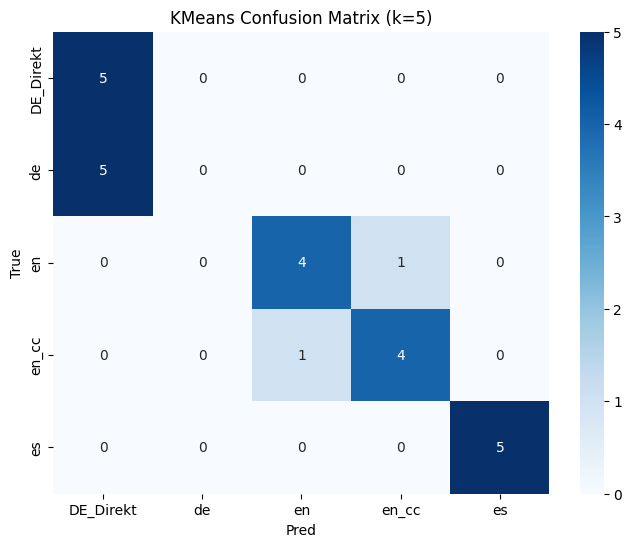

In [22]:
print(df["dataset_name"].value_counts())

min_count = df["dataset_name"].value_counts().min()

df, acc, cm = run_kmeans_evaluation(df, n_clusters=5, label_col='dataset_name', drop_cols=['dataset_name'], plot=True)

## NN

In [23]:
import scipy.sparse as sp
from sklearn.metrics import confusion_matrix



def run_nn(df, features, label_col="dataset_name", title="Neural Network"):


    X = df[features].values
    y = df[label_col].values

    if y.dtype.kind in {'O', 'U', 'S'}:  # string/object
        le = LabelEncoder()
        y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Length: {len(df)}, Train: {len(X_train)}, Test: {len(X_test)}")

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Ensure X is dense float64

    def to_dense_float(a):
        if sp.issparse(a):
            a = a.toarray()
        return np.asarray(a, dtype=np.float64)

    X_train_s = to_dense_float(X_train_s)
    X_test_s  = to_dense_float(X_test_s)


    # Ensure y is a plain 1D array (not sparse, not weird dtype)
    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)


    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)

    y_pred = mlp.predict(X_test_s)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    cm = confusion_matrix(y_test, y_pred)
    label_map = {i: cls for i, cls in enumerate(le.classes_)}  # Derived from actual data

    labels = sorted(label_map.keys())
    target_names = [label_map[i] for i in labels]

    print(
        "\nClassification Report:\n",
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            target_names=target_names,
            digits=4
        )
    )

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]

    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return mlp, accuracy, cm


### L2

Length: 25, Train: 20, Test: 5

===== MLP Classification of df =====
Test Accuracy: 0.6

Classification Report:
               precision    recall  f1-score   support

   DE_Direkt     0.0000    0.0000    0.0000         1
          de     0.5000    1.0000    0.6667         1
          en     0.0000    0.0000    0.0000         1
       en_cc     1.0000    1.0000    1.0000         1
          es     0.5000    1.0000    0.6667         1

    accuracy                         0.6000         5
   macro avg     0.4000    0.6000    0.4667         5
weighted avg     0.4000    0.6000    0.4667         5


Confusion matrix:
[[0 1 0 0 0]
 [0 1 0 0 0]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 0 1]]


c:\Users\Khushi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Khushi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Khushi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

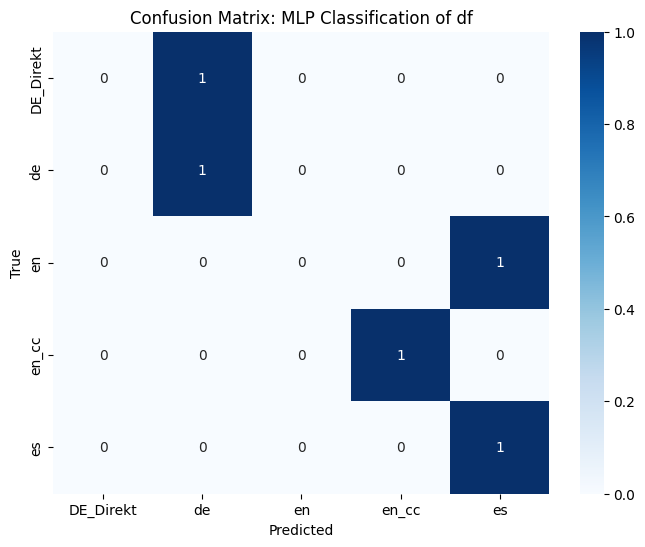

In [24]:
features = df.drop(columns=["dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df, features, label_col="dataset_name", title="MLP Classification of df")

In [ ]:
import os
 # Required packages
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def selectkbest_analysis(
    df,
    target_col='dataset_name',
    cols_to_drop=None,
    classes=None,
    k=10,
    output_dir='',
    zip_output=True
):

    DEFAULT_DROP = ['L1', 'dataset_name', 'cluster', 'kmeans_labels']
    all_to_drop  = list(set(DEFAULT_DROP + (cols_to_drop or [])))

    df_balanced  = df.copy().dropna()

    feature_cols = [c for c in df_balanced.columns if c not in all_to_drop]

    X_s          = df_balanced[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    y_balanced   = df_balanced[target_col].values
    
    X_s = X_s.to_numpy() if hasattr(X_s, "to_numpy") else np.asarray(X_s)
    y_balanced = np.asarray(y_balanced).ravel()

    # 1. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_s, y_balanced, stratify=y_balanced, random_state=42
    )

    # 2. Build class labels
    df_plot = df_balanced.copy()
    os.mkdir(output_dir)

    if 'dataset_name' in df_plot.columns:
        df_plot['class'] = (
            df_plot['dataset_name'].astype(str)
        )
        
    else:
        df_plot['class'] = df_plot[target_col].astype(str)

    if classes is None:
        classes = sorted(df_plot['class'].unique().tolist())

    # 3. SelectKBest
    selector     = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_s, y_balanced)
    top_idx      = selector.get_support(indices=True)
    top_features = [feature_cols[i] for i in top_idx]

    print(f"[{output_dir}] Top {k} features by ANOVA F-test: {top_features}")

    # 4. Output directory
    os.makedirs(output_dir, exist_ok=True)

    for f in top_features:
        df_plot[f] = pd.to_numeric(df_plot[f], errors='coerce')

    # 5. Boxplots
    for feat in top_features:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.boxplot(x='class', y=feat, data=df_plot, order=classes, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f"{feat}_boxplot.png"), dpi=300)
        plt.close(fig)

    # 6. KDE plots
    for feat in top_features:
        fig, ax = plt.subplots(figsize=(8, 4))
        for cls in classes:
            subset = df_plot[df_plot['class'] == cls]
            if not subset.empty:
                sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)
        ax.set_title(f"KDE of {feat} by class")
        ax.set_xlabel(feat)
        ax.set_ylabel("Density")
        ax.legend()
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f"{feat}_KDE.png"), dpi=300)
        plt.close(fig)

    # 7. Feature importance bar chart
    f_scores = selector.scores_[top_idx]
    p_values = selector.pvalues_[top_idx]

    importance_df = pd.DataFrame({
        'Feature': top_features,
        'F_score': f_scores,
        'p_value': p_values
    }).sort_values(by='F_score', ascending=False)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x='F_score', y='Feature', data=importance_df, ax=ax)
    ax.set_xlabel("ANOVA F-score")
    ax.set_ylabel("Feature")
    ax.set_title(f"Feature Importance - SelectKBest: ({output_dir})")
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, "Top_Feature_Importance_desc.png"), dpi=300)
    plt.show()
    plt.close(fig)

    # 8. zip
    if zip_output:
        os.system(f"zip -r {output_dir}.zip {output_dir}")
        print(f"Saved → {output_dir}.zip")


    return importance_df, top_features

[Subtitles_analysis] Top 10 features by ANOVA F-test: ['ppron', 'indef', 'relativ', 'mpred', 'infs', 'addit', 'simple', 'demdets', 'nnargs', 'xcomp']


C:\Users\Khushi\AppData\Local\Temp\ipykernel_22172\3882091954.py:89: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)
C:\Users\Khushi\AppData\Local\Temp\ipykernel_22172\3882091954.py:89: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)
C:\Users\Khushi\AppData\Local\Temp\ipykernel_22172\3882091954.py:89: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)


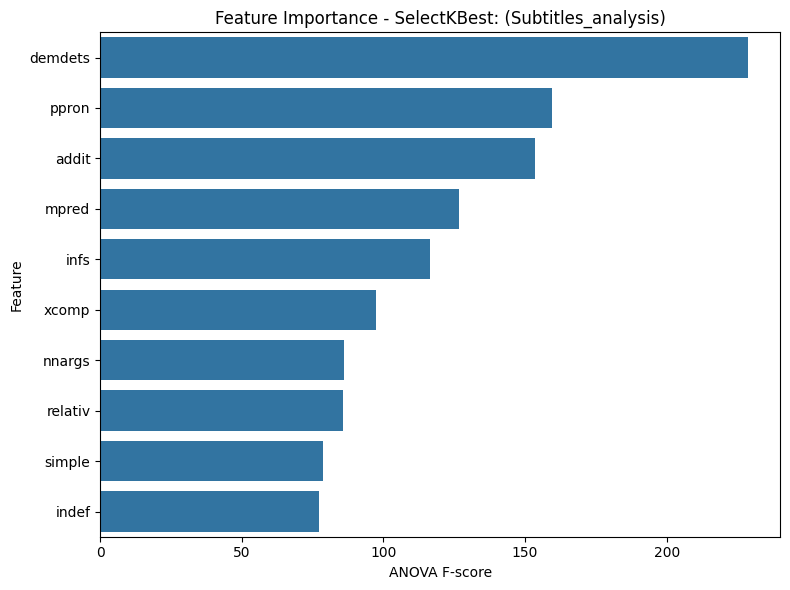

Saved → Subtitles_analysis.zip


(   Feature     F_score       p_value
 7  demdets  228.556343  2.180924e-16
 0    ppron  159.605601  7.152951e-15
 5    addit  153.585834  1.037096e-14
 3    mpred  126.511815  6.701452e-14
 4     infs  116.480963  1.477232e-13
 9    xcomp   97.424949  8.078322e-13
 8   nnargs   85.901807  2.649045e-12
 2  relativ   85.596347  2.739243e-12
 6   simple   78.651823  6.054450e-12
 1    indef   77.413438  7.022202e-12,
 ['ppron',
  'indef',
  'relativ',
  'mpred',
  'infs',
  'addit',
  'simple',
  'demdets',
  'nnargs',
  'xcomp'])

In [31]:
selectkbest_analysis(
    df,
    target_col='dataset_name',
    cols_to_drop=None,
    classes=None,
    k=10,
    output_dir="Subtitles_analysis",
    zip_output=True
)

In [27]:
df

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,nnargs,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp
0,de,0.110269,0.015952,0.003789,0.129032,0.012903,0.061290,0.001613,0.003226,0.154839,...,0.323108,2.352672,0.905017,0.030108,0.169086,0.002016,0.050269,0.001613,0.031586,0.037903
1,de,0.116029,0.011375,0.002482,0.172043,0.007168,0.051971,0.000000,0.000000,0.179211,...,0.262189,2.309379,0.972196,0.015355,0.194714,0.004174,0.068149,0.003280,0.039356,0.038121
2,de,0.126670,0.014313,0.001670,0.157025,0.006198,0.053719,0.002066,0.002066,0.225207,...,0.233293,2.294341,1.001007,0.031164,0.202135,0.003788,0.053030,0.004304,0.058196,0.048209
3,de,0.110545,0.011218,0.001632,0.141176,0.013445,0.055462,0.001681,0.005042,0.178151,...,0.268528,2.305291,0.983947,0.025210,0.228768,0.003922,0.040784,0.003922,0.046835,0.023669
4,de,0.111410,0.013632,0.003198,0.185351,0.005979,0.067265,0.005979,0.001495,0.155456,...,0.294793,2.382202,0.945262,0.036273,0.125685,0.004335,0.060962,0.001594,0.039462,0.044096
5,en,0.112920,0.020905,0.005826,0.123755,0.019915,0.075391,0.001422,0.000000,0.251778,...,0.291627,2.341280,0.787847,0.021029,0.241323,0.005808,0.027786,0.005097,0.050972,0.097487
6,en,0.115827,0.012495,0.004958,0.158416,0.011551,0.064356,0.000000,0.000000,0.287129,...,0.259783,2.283965,0.790839,0.007825,0.266008,0.008387,0.035844,0.008936,0.063157,0.100781
7,en,0.121547,0.015470,0.005304,0.167702,0.028986,0.072464,0.002070,0.000000,0.401656,...,0.224566,2.263203,0.869011,0.013630,0.269772,0.004037,0.049586,0.003692,0.103175,0.108903
8,en,0.114446,0.012547,0.006952,0.159322,0.018644,0.067797,0.001695,0.000000,0.322034,...,0.226453,2.324858,0.912404,0.026570,0.270065,0.008632,0.031073,0.009237,0.105698,0.113132
9,en,0.116837,0.015905,0.004588,0.191837,0.014966,0.068027,0.000000,0.000000,0.322449,...,0.271028,2.357634,0.829125,0.014810,0.268071,0.010009,0.042097,0.009330,0.044520,0.104370
